# NB01: State Population & Demographics

**Purpose:** Build a base table of all 50 states + DC with population, adult population (18+), age distribution, and Octave current-state flag. This becomes the denominator for all per-capita calculations downstream.

**Data Sources:**
- U.S. Census Bureau Population Estimates API (2024 vintage)
- Census Bureau ACS 5-Year age/sex estimates

**Outputs:**
- `state_population_base.csv` — one row per state with population, adult pop, age bands, Octave flag

---

In [1]:
import pandas as pd
import numpy as np
import requests
import json
import os
import warnings
warnings.filterwarnings('ignore')

# Project paths
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'data', 'outputs', 'nb01_census_population')
INPUT_DIR = os.path.join(PROJECT_ROOT, 'data', 'inputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(INPUT_DIR, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Output dir: {OUTPUT_DIR}")

Project root: /Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/octave_behavioral_health_expansion
Output dir: /Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/octave_behavioral_health_expansion/data/outputs/nb01_census_population


## 1. Define Octave's Current Footprint

23 states + DC where Octave currently operates.

In [2]:
# =============================================================================
# SCOPE: 50 states + DC only. US territories (PR, GU, VI, AS, MP) are excluded
# because NSDUH, MHA, and most payer data sources do not cover them consistently.
# =============================================================================

# Octave's current 23 states + DC
OCTAVE_STATES = [
    'Arizona', 'California', 'Colorado', 'Connecticut', 'Florida',
    'Georgia', 'Illinois', 'Maryland', 'Massachusetts', 'Minnesota',
    'New Jersey', 'New York', 'North Carolina', 'Ohio', 'Oregon',
    'Pennsylvania', 'South Carolina', 'Tennessee', 'Texas', 'Virginia',
    'Washington', 'Wisconsin', 'District of Columbia'
]

# FIPS codes for all 50 states + DC
STATE_FIPS = {
    '01': 'Alabama', '02': 'Alaska', '04': 'Arizona', '05': 'Arkansas',
    '06': 'California', '08': 'Colorado', '09': 'Connecticut', '10': 'Delaware',
    '11': 'District of Columbia', '12': 'Florida', '13': 'Georgia', '15': 'Hawaii',
    '16': 'Idaho', '17': 'Illinois', '18': 'Indiana', '19': 'Iowa',
    '20': 'Kansas', '21': 'Kentucky', '22': 'Louisiana', '23': 'Maine',
    '24': 'Maryland', '25': 'Massachusetts', '26': 'Michigan', '27': 'Minnesota',
    '28': 'Mississippi', '29': 'Missouri', '30': 'Montana', '31': 'Nebraska',
    '32': 'Nevada', '33': 'New Hampshire', '34': 'New Jersey', '35': 'New Mexico',
    '36': 'New York', '37': 'North Carolina', '38': 'North Dakota', '39': 'Ohio',
    '40': 'Oklahoma', '41': 'Oregon', '42': 'Pennsylvania', '44': 'Rhode Island',
    '45': 'South Carolina', '46': 'South Dakota', '47': 'Tennessee', '48': 'Texas',
    '49': 'Utah', '50': 'Vermont', '51': 'Virginia', '53': 'Washington',
    '54': 'West Virginia', '55': 'Wisconsin', '56': 'Wyoming'
}

# State abbreviations for downstream use
STATE_ABBREV = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR',
    'California': 'CA', 'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE',
    'District of Columbia': 'DC', 'Florida': 'FL', 'Georgia': 'GA', 'Hawaii': 'HI',
    'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA',
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME',
    'Maryland': 'MD', 'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN',
    'Mississippi': 'MS', 'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE',
    'Nevada': 'NV', 'New Hampshire': 'NH', 'New Jersey': 'NJ', 'New Mexico': 'NM',
    'New York': 'NY', 'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH',
    'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI',
    'South Carolina': 'SC', 'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX',
    'Utah': 'UT', 'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA',
    'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY'
}

print(f"Octave operates in {len(OCTAVE_STATES)} states/jurisdictions")
print(f"Expansion target: {51 - len(OCTAVE_STATES)} additional states")

Octave operates in 23 states/jurisdictions
Expansion target: 28 additional states


## 2. Pull State Population from Census API

We use the Census Population Estimates Program (PEP) for the most current population figures, and ACS for age breakdowns.

In [3]:
# --- Census API Configuration ---
# Get a free API key at: https://api.census.gov/data/key_signup.html
# For now, we can query without a key (limited rate)
CENSUS_API_KEY = None  # Replace with your key: 'YOUR_KEY_HERE'

def census_api_call(url, params=None):
    """Make a Census API call with error handling."""
    if CENSUS_API_KEY:
        if params is None:
            params = {}
        params['key'] = CENSUS_API_KEY
    
    resp = requests.get(url, params=params, timeout=30)
    resp.raise_for_status()
    data = resp.json()
    
    # Census API returns header row + data rows
    df = pd.DataFrame(data[1:], columns=data[0])
    return df

print("Census API helper ready.")

Census API helper ready.


In [4]:
# --- Pull total population by state (2023 ACS 1-Year estimates) ---
# Table B01001: Sex by Age
# We pull total population and age groups to calculate adult (18+) population

ACS_BASE = 'https://api.census.gov/data/2023/acs/acs1'

# B01001: Total population by sex and age
# B01001_001E = total population
# We need age groups to calculate 18+ population
# Age groups in B01001 (male): _003 to _025, (female): _027 to _049
# Under 18 male: _003 to _006 (under 5, 5-9, 10-14, 15-17)
# Under 18 female: _027 to _030

age_vars = [
    'B01001_001E',  # Total population
    'B01001_003E', 'B01001_004E', 'B01001_005E', 'B01001_006E',  # Male <5, 5-9, 10-14, 15-17
    'B01001_027E', 'B01001_028E', 'B01001_029E', 'B01001_030E',  # Female <5, 5-9, 10-14, 15-17
    'NAME'
]

url = f"{ACS_BASE}?get={','.join(age_vars)}&for=state:*"
print(f"Querying: {ACS_BASE}")

try:
    df_pop = census_api_call(url)
    print(f"Retrieved {len(df_pop)} rows (states + DC)")
    df_pop.head(3)
except Exception as e:
    print(f"API call failed: {e}")
    print("Falling back to manual population data...")
    df_pop = None

Querying: https://api.census.gov/data/2023/acs/acs1


Retrieved 52 rows (states + DC)


In [5]:
# --- Process population data ---

if df_pop is not None:
    # Convert numeric columns
    numeric_cols = [c for c in df_pop.columns if c.startswith('B01001')]
    for col in numeric_cols:
        df_pop[col] = pd.to_numeric(df_pop[col], errors='coerce')
    
    # Calculate populations
    df_pop['total_population'] = df_pop['B01001_001E']
    
    # Under 18 = sum of male under-18 groups + female under-18 groups
    under_18_male = ['B01001_003E', 'B01001_004E', 'B01001_005E', 'B01001_006E']
    under_18_female = ['B01001_027E', 'B01001_028E', 'B01001_029E', 'B01001_030E']
    df_pop['population_under_18'] = df_pop[under_18_male + under_18_female].sum(axis=1)
    df_pop['population_18_plus'] = df_pop['total_population'] - df_pop['population_under_18']
    df_pop['pct_adult'] = (df_pop['population_18_plus'] / df_pop['total_population'] * 100).round(1)
    
    # Clean up
    df_pop = df_pop.rename(columns={'NAME': 'state_name', 'state': 'fips_code'})
    df_pop['state_abbrev'] = df_pop['state_name'].map(STATE_ABBREV)
    df_pop['is_octave_state'] = df_pop['state_name'].isin(OCTAVE_STATES)
    
    # Filter to only 50 states + DC (drop territories like Puerto Rico)
    df_pop = df_pop.dropna(subset=['state_abbrev'])
    
    # Select final columns
    df_base = df_pop[[
        'fips_code', 'state_name', 'state_abbrev', 'is_octave_state',
        'total_population', 'population_18_plus', 'population_under_18', 'pct_adult'
    ]].copy()
    
    df_base = df_base.sort_values('state_name').reset_index(drop=True)
    
    print(f"\nBase table: {len(df_base)} states/jurisdictions")
    print(f"Octave states: {df_base['is_octave_state'].sum()}")
    print(f"Expansion states: {(~df_base['is_octave_state']).sum()}")
    print(f"\nTotal U.S. population: {df_base['total_population'].sum():,.0f}")
    print(f"Total adult (18+): {df_base['population_18_plus'].sum():,.0f}")
    df_base.head(10)
else:
    print("No API data — see fallback cell below.")


Base table: 51 states/jurisdictions
Octave states: 23
Expansion states: 28

Total U.S. population: 334,914,896
Total adult (18+): 262,266,460


In [6]:
# --- Fallback: Manual population data if Census API is unavailable ---
# Source: Census Bureau 2024 population estimates
# This cell only runs if the API call above failed

if df_pop is None:
    print("Using fallback population estimates (Census Bureau 2024)...")
    
    # 2024 Census population estimates (rounded to nearest thousand)
    fallback_data = {
        'Alabama': 5108468, 'Alaska': prior_733583, 'Arizona': 7431344,
        'Arkansas': 3067732, 'California': 38965193, 'Colorado': 5877610,
        'Connecticut': 3617176, 'Delaware': 1018396, 'District of Columbia': 678972,
        'Florida': 22610726, 'Georgia': 11029227, 'Hawaii': 1435138,
        'Idaho': 1964726, 'Illinois': 12549689, 'Indiana': 6862199,
        'Iowa': 3207004, 'Kansas': 2940546, 'Kentucky': 4526154,
        'Louisiana': 4573749, 'Maine': 1395722, 'Maryland': 6180253,
        'Massachusetts': 7001399, 'Michigan': 10037261, 'Minnesota': 5737915,
        'Mississippi': 2939690, 'Missouri': 6196156, 'Montana': 1132812,
        'Nebraska': 1978379, 'Nevada': 3194176, 'New Hampshire': 1402054,
        'New Jersey': 9290841, 'New Mexico': 2114371, 'New York': 19571216,
        'North Carolina': 10835491, 'North Dakota': 783926, 'Ohio': 11785935,
        'Oklahoma': 4019800, 'Oregon': 4233358, 'Pennsylvania': 12961683,
        'Rhode Island': 1095962, 'South Carolina': 5373555, 'South Dakota': 919318,
        'Tennessee': 7126489, 'Texas': 30503301, 'Utah': 3417734,
        'Vermont': 647464, 'Virginia': 8642274, 'Washington': 7812880,
        'West Virginia': 1770071, 'Wisconsin': 5893718, 'Wyoming': 576851
    }
    
    # Note: this fallback doesn't have age breakdowns
    # We'll estimate adult pop as ~78% (national average)
    df_base = pd.DataFrame([
        {
            'state_name': state,
            'state_abbrev': STATE_ABBREV[state],
            'fips_code': [k for k, v in STATE_FIPS.items() if v == state][0],
            'is_octave_state': state in OCTAVE_STATES,
            'total_population': pop,
            'population_18_plus': int(pop * 0.78),
            'population_under_18': int(pop * 0.22),
            'pct_adult': 78.0
        }
        for state, pop in fallback_data.items()
    ])
    df_base = df_base.sort_values('state_name').reset_index(drop=True)
    print(f"Fallback table: {len(df_base)} states")
    print("NOTE: Adult pop is estimated at 78% — replace with API data when available.")

## 3. Summary Statistics

In [7]:
# --- Population summary: Octave states vs. expansion states ---

summary = df_base.groupby('is_octave_state').agg(
    n_states=('state_name', 'count'),
    total_pop=('total_population', 'sum'),
    total_adult=('population_18_plus', 'sum'),
    avg_pop=('total_population', 'mean'),
    median_pop=('total_population', 'median'),
    min_pop=('total_population', 'min'),
    max_pop=('total_population', 'max')
).reset_index()

summary['is_octave_state'] = summary['is_octave_state'].map({True: 'Current Octave', False: 'Expansion Target'})
summary = summary.rename(columns={'is_octave_state': 'segment'})

# Format for display
for col in ['total_pop', 'total_adult', 'avg_pop', 'median_pop', 'min_pop', 'max_pop']:
    summary[col] = summary[col].apply(lambda x: f"{x:,.0f}")

print("Population Summary: Octave States vs. Expansion Targets")
print("=" * 70)
summary

Population Summary: Octave States vs. Expansion Targets


,segment,n_states,total_pop,total_adult,avg_pop,median_pop,min_pop,max_pop
0,Expansion Target,28,"79,113,990","61,469,884","2,825,500","2,046,375","584,057","10,037,261"
1,Current Octave,23,"255,800,906","200,796,576","11,121,779","7,812,880","678,972","38,965,193"


In [8]:
# --- Top 10 expansion states by adult population ---

expansion = df_base[~df_base['is_octave_state']].sort_values('population_18_plus', ascending=False)

print("Top 10 Expansion States by Adult Population (18+)")
print("=" * 50)
for i, row in expansion.head(10).iterrows():
    print(f"  {row['state_abbrev']:>2}  {row['state_name']:<20} {row['population_18_plus']:>12,.0f} adults")

print(f"\nTotal adult pop in expansion states: {expansion['population_18_plus'].sum():,.0f}")
print(f"Total adult pop in Octave states:    {df_base[df_base['is_octave_state']]['population_18_plus'].sum():,.0f}")

Top 10 Expansion States by Adult Population (18+)
  MI  Michigan                7,926,790 adults
  IN  Indiana                 5,281,293 adults
  MO  Missouri                4,824,817 adults
  AL  Alabama                 3,978,822 adults
  KY  Kentucky                3,514,417 adults
  LA  Louisiana               3,510,313 adults
  OK  Oklahoma                3,088,080 adults
  NV  Nevada                  2,509,660 adults
  UT  Utah                    2,483,829 adults
  IA  Iowa                    2,481,457 adults

Total adult pop in expansion states: 61,469,884
Total adult pop in Octave states:    200,796,576


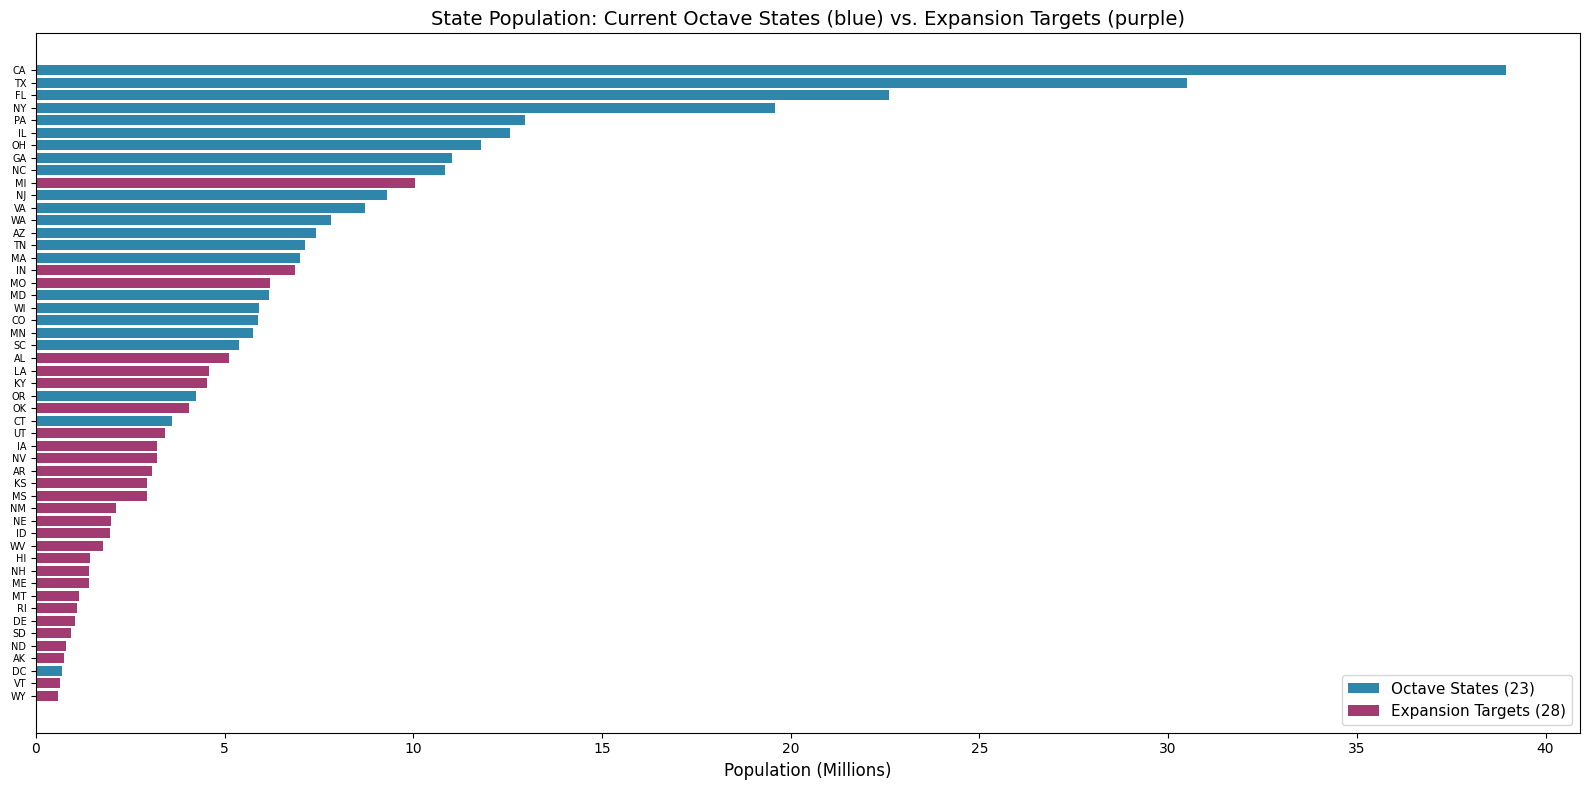

Saved: state_population_overview.png


In [9]:
# --- Quick bar chart: population by state, colored by Octave status ---

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 8))

df_plot = df_base.sort_values('total_population', ascending=True)
colors = ['#2E86AB' if x else '#A23B72' for x in df_plot['is_octave_state']]

ax.barh(df_plot['state_abbrev'], df_plot['total_population'] / 1e6, color=colors)
ax.set_xlabel('Population (Millions)', fontsize=12)
ax.set_title('State Population: Current Octave States (blue) vs. Expansion Targets (purple)', fontsize=14)
ax.tick_params(axis='y', labelsize=7)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2E86AB', label=f'Octave States ({df_base["is_octave_state"].sum()})'),
    Patch(facecolor='#A23B72', label=f'Expansion Targets ({(~df_base["is_octave_state"]).sum()})')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'state_population_overview.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: state_population_overview.png")

## 4. Save Output

In [10]:
# --- Save the base population table ---

output_path = os.path.join(OUTPUT_DIR, 'state_population_base.csv')
df_base.to_csv(output_path, index=False)

print(f"Saved: {output_path}")
print(f"Shape: {df_base.shape}")
print(f"\nColumns: {list(df_base.columns)}")
print(f"\nThis table is the base for all downstream notebooks.")
print(f"Every per-capita metric will use total_population or population_18_plus as the denominator.")

Saved: /Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/octave_behavioral_health_expansion/data/outputs/nb01_census_population/state_population_base.csv
Shape: (51, 8)

Columns: ['fips_code', 'state_name', 'state_abbrev', 'is_octave_state', 'total_population', 'population_18_plus', 'population_under_18', 'pct_adult']

This table is the base for all downstream notebooks.
Every per-capita metric will use total_population or population_18_plus as the denominator.


In [11]:
# --- Also save the reference dictionaries for downstream notebooks ---

import json

reference = {
    'octave_states': OCTAVE_STATES,
    'state_fips': STATE_FIPS,
    'state_abbrev': STATE_ABBREV,
    'octave_payers': [
        'Aetna', 'Anthem Blue Cross of California', 'Blue Shield of California',
        'Blue Cross Blue Shield', 'Centivo', 'Florida Blue', 'Health Net',
        'Highmark', 'Horizon Health NJ', 'MHN', 'UMR', 'Cigna', 'Evernorth',
        'UnitedHealthcare', 'Optum'
    ],
    'competitors': {
        'Rula': {'states': 'all_50', 'providers': '10000+', 'covered_lives': '120M+', 'funding': '$200M+'},
        'Grow Therapy': {'states': 'all_50', 'providers': '10000+', 'covered_lives': 'undisclosed', 'funding': '$175M+'},
        'Headway': {'states': 'all_50', 'providers': '60000+', 'covered_lives': '100M+', 'funding': '$225M+'},
        'Alma': {'states': 'all_50', 'providers': '20000+', 'covered_lives': 'undisclosed', 'funding': '$130M+'}
    }
}

ref_path = os.path.join(INPUT_DIR, 'project_reference.json')
with open(ref_path, 'w') as f:
    json.dump(reference, f, indent=2)

print(f"Saved: {ref_path}")
print("Contains: octave_states, state_fips, state_abbrev, octave_payers, competitors")

Saved: /Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/octave_behavioral_health_expansion/data/inputs/project_reference.json
Contains: octave_states, state_fips, state_abbrev, octave_payers, competitors


---

## Next: NB02 — Behavioral Health Provider Landscape

NB02 will use `state_population_base.csv` as the denominator to calculate provider-to-population ratios by state.